# CELL 1

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder

# Thư viện Deep Learning Keras/TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, Flatten, BatchNormalization, Conv1D, MaxPooling1D, Bidirectional, Input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical

DATASET_PATH = "../DATASET_LABELED"
SAMPLE_RATE = 16000
DURATION = 4.0 
N_MFCC = 20

# Định nghĩa nhãn (Lưu ý: Bạn có 5 nhãn)
EMOTION_MAP = {
    "ANG": 0, # angry
    "ANX": 1, # anxious
    "HAP": 2, # happy
    "NEU": 3, # neutral
    "SAD": 4  # sad
}
# Đảo ngược để in kết quả sau này
idx_to_emotion = {v: k for k, v in EMOTION_MAP.items()}

print("Đã import xong!")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "e:\anaconda3\envs\ser\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "e:\anaconda3\envs\ser\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "e:\anaconda3\envs\ser\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "e:\anaconda3\envs\ser\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "e:\anaconda3\envs\ser\lib\site-packages\ipykernel

AttributeError: _ARRAY_API not found

Đã import xong!


# CELL 2

In [2]:
# 1. Các hàm làm méo tiếng (Data Augmentation)
def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)

# 2. Hàm xử lý độ dài (Padding/Truncate)
def pad_audio(data, sr, duration=4.0):
    input_length = int(sr * duration)
    if len(data) > input_length:
        # Nếu dài hơn 4s thì cắt bớt
        data = data[:input_length]
    else:
        # Nếu ngắn hơn 4s thì thêm số 0 vào đuôi (padding)
        padding = input_length - len(data)
        data = np.pad(data, (0, padding), 'constant')
    return data

# 3. Hàm tổng hợp để load và xử lý
def process_audio_file(file_path, augment=False):
    # Load file
    data, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    
    # Cắt khoảng lặng (Trim silence)
    data, _ = librosa.effects.trim(data, top_db=25)
    
    # Nếu yêu cầu augment (làm méo tiếng)
    if augment:
        # Random chọn 1 loại biến đổi để áp dụng
        choice = random.choice(['noise', 'stretch', 'shift', 'pitch'])
        if choice == 'noise': data = noise(data)
        elif choice == 'stretch': data = stretch(data)
        elif choice == 'shift': data = shift(data)
        elif choice == 'pitch': data = pitch(data, sr)
            
    # Ép về độ dài chuẩn 4s
    data = pad_audio(data, sr, DURATION)
    return data

# CELL 3

In [3]:
def extract_features(data, sr):
    # 1. ZCR
    zcr = librosa.feature.zero_crossing_rate(y=data, frame_length=2048, hop_length=512)
    # 2. RMS Energy
    rms = librosa.feature.rms(y=data, frame_length=2048, hop_length=512)
    # 3. MFCC
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=N_MFCC, hop_length=512)
    
    # Ghép tất cả lại: Kết quả sẽ là (Số features, Thời gian)
    # Ví dụ: (1 + 1 + 20, 126) = (22, 126)
    features = np.concatenate((zcr, rms, mfcc), axis=0)
    
    # Chuyển vị ma trận thành (Thời gian, Số features) để đưa vào LSTM/CNN
    # Kết quả: (126, 22)
    return features.T 

print("Đã khai báo hàm trích xuất đặc trưng.")

Đã khai báo hàm trích xuất đặc trưng.


# CELL 4

In [4]:
X = []
y = []

print("Đang xử lý dữ liệu...")

# Duyệt qua các thư mục
for folder_name in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder_name)
    
    # Chỉ xử lý nếu tên folder nằm trong map (ANG, HAP...)
    if os.path.isdir(folder_path) and folder_name in EMOTION_MAP:
        emotion_label = EMOTION_MAP[folder_name]
        print(f"-> Đang xử lý nhãn: {folder_name}")
        
        for file_path in glob.glob(os.path.join(folder_path, "*.wav")):
            # 1. Lấy dữ liệu gốc (Original)
            sig = process_audio_file(file_path, augment=False)
            feat = extract_features(sig, SAMPLE_RATE)
            X.append(feat)
            y.append(emotion_label)
            
            # 2. Tạo thêm dữ liệu giả (Augmentation)
            # Giúp tăng số lượng mẫu và model thông minh hơn
            # Tạo thêm 1 bản copy bị méo tiếng cho mỗi file gốc
            sig_aug = process_audio_file(file_path, augment=True)
            feat_aug = extract_features(sig_aug, SAMPLE_RATE)
            X.append(feat_aug)
            y.append(emotion_label)

# Chuyển sang mảng Numpy
X = np.array(X)
y = np.array(y)

# One-hot encoding cho nhãn (VD: nhãn 0 -> [1, 0, 0, 0, 0])
y_onehot = to_categorical(y, num_classes=5) # Bạn có 5 lớp

print("\nHoàn tất!")
print(f"Shape của X: {X.shape}") # (Số mẫu, Time_steps, Features)
print(f"Shape của y: {y_onehot.shape}")

# Chia Train/Test/Val
# Train: 80%, Test: 20%
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Đang xử lý dữ liệu...
-> Đang xử lý nhãn: ANG
-> Đang xử lý nhãn: ANX
-> Đang xử lý nhãn: HAP
-> Đang xử lý nhãn: NEU
-> Đang xử lý nhãn: SAD

Hoàn tất!
Shape của X: (3356, 126, 22)
Shape của y: (3356, 5)
Train samples: 2415
Test samples: 672


# CELL 5

In [5]:
rlrop = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Lấy shape đầu vào từ dữ liệu đã xử lý
input_shape = (X_train.shape[1], X_train.shape[2]) # (Time_steps, Features)
num_classes = 5 # ANG, ANX, HAP, NEU, SAD

# CELL 6 Model 1 - LSTM (Long Short-Term Memory)

In [6]:
model_lstm = Sequential([
    Input(shape=input_shape),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model_lstm.summary())

history_lstm = model_lstm.fit(X_train, y_train, epochs=50, batch_size=32, 
                              validation_data=(X_val, y_val), 
                              callbacks=[rlrop, early_stopping])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 126, 128)       │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 126, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,205 (512.52 KB)

 Trainable params: 131,205 (512.52 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.4704 - loss: 1.4107 - val_accuracy: 0.5651 - val_loss: 1.2645 - learning_rate: 0.0010
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.5399 - loss: 1.2738 - val_accuracy: 0.5204 - val_loss: 1.3199 - learning_rate: 0.0010
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.5261 - loss: 1.2636 - val_accuracy: 0.5279 - val_loss: 1.2426 - learning_rate: 0.0010
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.5544 - loss: 1.2155 - val_accuracy: 0.5279 - val_loss: 1.2495 - learning_rate: 0.0010
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.5744 - loss: 1.1649 - val_accuracy: 0.5279 - val_loss: 1.2228 - learning_rate: 0.0010
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5966 - loss: 1.1015
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5966 - loss: 1.1016 - val

# CELL 7 Model 2 - Bi-LSTM (Bidirectional LSTM)

In [7]:
model_bilstm = Sequential([
    Input(shape=input_shape),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_bilstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_bilstm = model_bilstm.fit(X_train, y_train, epochs=50, batch_size=32, 
                                  validation_data=(X_val, y_val), 
                                  callbacks=[rlrop, early_stopping])

Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.4382 - loss: 1.4371 - val_accuracy: 0.5539 - val_loss: 1.3018 - learning_rate: 0.0010
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5360 - loss: 1.2586 - val_accuracy: 0.5576 - val_loss: 1.1852 - learning_rate: 0.0010
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5639 - loss: 1.1892 - val_accuracy: 0.5874 - val_loss: 1.1971 - learning_rate: 0.0010
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6094 - loss: 1.0800 - val_accuracy: 0.5836 - val_loss: 1.1303 - learning_rate: 0.0010
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6152 - loss: 1.0274 - val_accuracy: 0.5874 - val_loss: 1.1595 - learning_rate: 0.0010
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6312 - loss: 1.0002 - val_accuracy: 0.6022 - val_loss: 1.1226 - learning_rate: 0.0010
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6473 - loss: 0.9510 - val_acc

# CELL 8 Model 3 - CNN (Convolutional Neural Network 1D)

In [8]:
model_cnn = Sequential([
    Input(shape=input_shape),
    Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(128, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_cnn = model_cnn.fit(X_train, y_train, epochs=50, batch_size=32, 
                            validation_data=(X_val, y_val), 
                            callbacks=[rlrop, early_stopping])

Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4149 - loss: 1.8655 - val_accuracy: 0.5651 - val_loss: 1.2405 - learning_rate: 0.0010
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6158 - loss: 1.0284 - val_accuracy: 0.5613 - val_loss: 1.2125 - learning_rate: 0.0010
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7081 - loss: 0.7958 - val_accuracy: 0.5799 - val_loss: 1.0965 - learning_rate: 0.0010
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7965 - loss: 0.5897 - val_accuracy: 0.6171 - val_loss: 1.1411 - learning_rate: 0.0010
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8822 - loss: 0.3798 - val_accuracy: 0.6691 - val_loss: 1.2132 - learning_rate: 0.0010
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8917 - loss: 0.2901 - val_accuracy: 0.6320 - val_loss: 1.2707 - learning_rate: 0.0010
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9343 - loss: 0.2087 - val_accuracy:

# Cell 9 

SO SÁNH KẾT QUẢ CÁC MODEL

LSTM:
  Test Loss: 0.9594
  Test Accuracy: 67.71%

Bi-LSTM:
  Test Loss: 0.8964
  Test Accuracy: 69.64%

CNN:
  Test Loss: 1.1052
  Test Accuracy: 61.01%

🏆 MODEL TỐT NHẤT: Bi-LSTM với accuracy 69.64%


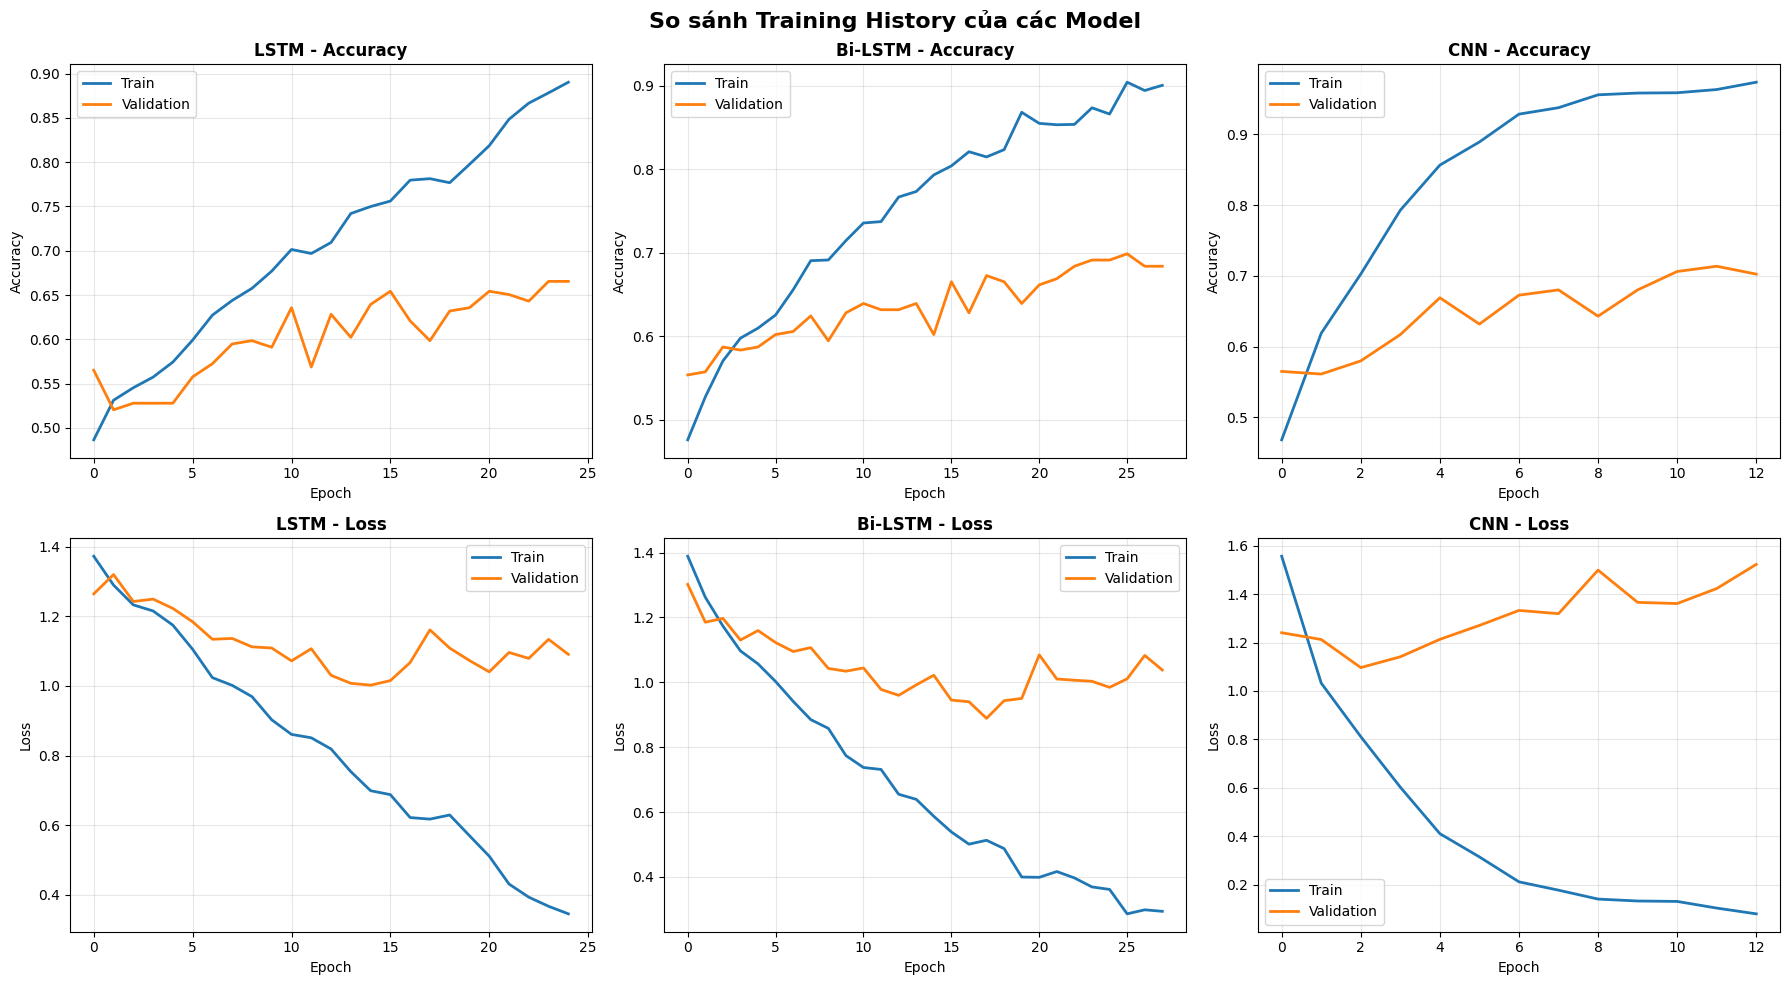

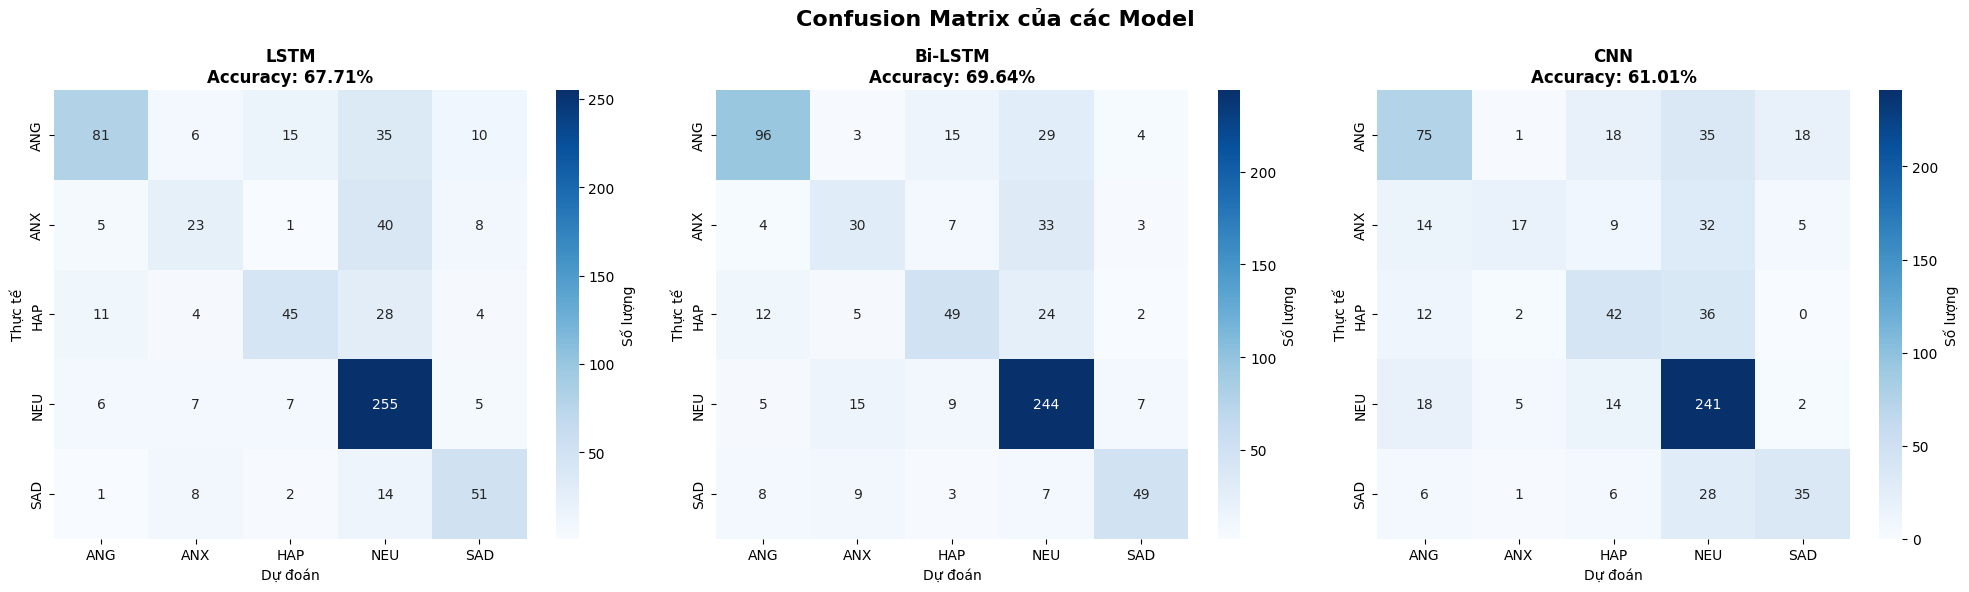


CLASSIFICATION REPORT CHO Bi-LSTM (Model tốt nhất)
              precision    recall  f1-score   support

         ANG     0.7680    0.6531    0.7059       147
         ANX     0.4839    0.3896    0.4317        77
         HAP     0.5904    0.5326    0.5600        92
         NEU     0.7240    0.8714    0.7909       280
         SAD     0.7538    0.6447    0.6950        76

    accuracy                         0.6964       672
   macro avg     0.6640    0.6183    0.6367       672
weighted avg     0.6912    0.6964    0.6887       672



In [9]:
# So sánh và đánh giá cả 3 model
models = {
    'LSTM': (model_lstm, history_lstm),
    'Bi-LSTM': (model_bilstm, history_bilstm),
    'CNN': (model_cnn, history_cnn)
}

print("="*60)
print("SO SÁNH KẾT QUẢ CÁC MODEL")
print("="*60)

results = {}
for model_name, (model, history) in models.items():
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[model_name] = {'loss': loss, 'accuracy': acc}
    print(f"\n{model_name}:")
    print(f"  Test Loss: {loss:.4f}")
    print(f"  Test Accuracy: {acc*100:.2f}%")

# Tìm model tốt nhất
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print("\n" + "="*60)
print(f"🏆 MODEL TỐT NHẤT: {best_model_name} với accuracy {results[best_model_name]['accuracy']*100:.2f}%")
print("="*60)

# 1. Vẽ đồ thị Loss và Accuracy cho cả 3 model
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('So sánh Training History của các Model', fontsize=16, fontweight='bold')

for idx, (model_name, (model, history)) in enumerate(models.items()):
    # Accuracy
    axes[0, idx].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0, idx].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, idx].set_title(f'{model_name} - Accuracy', fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Accuracy')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Loss
    axes[1, idx].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1, idx].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[1, idx].set_title(f'{model_name} - Loss', fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Loss')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Vẽ Confusion Matrix cho cả 3 model
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix của các Model', fontsize=16, fontweight='bold')

for idx, (model_name, (model, history)) in enumerate(models.items()):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    cm = confusion_matrix(y_true, y_pred_classes)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=list(EMOTION_MAP.keys()), 
                yticklabels=list(EMOTION_MAP.keys()),
                cbar_kws={'label': 'Số lượng'})
    axes[idx].set_title(f'{model_name}\nAccuracy: {results[model_name]["accuracy"]*100:.2f}%', 
                        fontweight='bold')
    axes[idx].set_xlabel('Dự đoán')
    axes[idx].set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

# 3. Classification Report chi tiết cho model tốt nhất
print("\n" + "="*60)
print(f"CLASSIFICATION REPORT CHO {best_model_name} (Model tốt nhất)")
print("="*60)
best_model = models[best_model_name][0]
y_pred_best = best_model.predict(X_test, verbose=0)
y_pred_classes_best = np.argmax(y_pred_best, axis=1)
y_true_best = np.argmax(y_test, axis=1)

print(classification_report(y_true_best, y_pred_classes_best, 
                          target_names=list(EMOTION_MAP.keys()),
                          digits=4))